In [2]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [3]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle
# from pathlib import Path
import os

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_gold", [BLUE, YELLOW], N=256)

In [4]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)


def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

In [5]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'

In [6]:
VEL_SCALE = 10   # divide all velocities by 10 -> feature scales comparable, ~isotropic parameter space

In [7]:
CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.07

def draw_cartpole(ax, cart_x, pole_theta, action=None):
    ax.set_xlim(-2.4, 2.4); ax.set_ylim(-0.55, 1.75)
    ax.set_aspect('equal'); ax.axis('off')
    ax.plot([-2.4, 2.4], [0, 0], color=CHILL_BROWN, lw=1.5, zorder=1)   # track
    cart_y = WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, WHEEL_R), WHEEL_R, color=CHILL_BROWN, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc='#3a3a3a', ec=CHILL_BROWN, lw=1.5, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color='w', lw=6, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.045, color=CHILL_BROWN, zorder=6))
    if action is not None:   # action arrow under the cart, your color convention
        ax.scatter([cart_x], [-0.32],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=420,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)

In [8]:
RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

ANG_LIM = (-13, 13) #Ok I want this to be in degrees!
VEL_LIM = (-17, 17)   # angvel data is pre-divided by VEL_SCALE=10

## 0. Some setup and baselines

In [9]:
# class Pi(nn.Module):
#     """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity.

#     P(right) = sigmoid(logit). Returns [P(left), P(right)] with shape (2,) or (T, 2),
#     so the REINFORCE loop below is unchanged from the neural net version.
#     """
#     def __init__(self):
#         super().__init__()
#         self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

#     def forward(self, x):
#         feats = x[..., 2:4]                # state indices 2, 3: pole angle, pole angular velocity
#         logit = feats @ self.theta         # scalar or (T,)
#         p_right = torch.sigmoid(logit)
#         return torch.stack([1.0 - p_right, p_right], dim=-1)

In [10]:
# This might be cleaner scaling wise, but I have a good amount of tech debt doing it the other way
# let me see if I can get the job done w/o this. 

class Pi(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))

    def forward(self, x):
        feats = x[..., 2:4] * (180 / np.pi)   # degree-scale features
        logit = feats @ self.theta
        p_right = torch.sigmoid(logit)
        return torch.stack([1.0 - p_right, p_right], dim=-1)

In [11]:
def scale_state(s):
    s = s.astype(np.float32).copy()
    s[1] /= VEL_SCALE; s[3] /= VEL_SCALE   # same /10 velocity scaling as the demo data
    return s

def run_rollout(seed, deterministic=False):
    # --- rollout: collect one episode ---
    states, actions, rewards = [], [], []
    state, _ = env.reset(seed=seed)
    state = scale_state(state)
    for t in range(500):                                # CartPole-v1 max timestep is 500
        with torch.no_grad():                           # no graph needed here; we recompute below
            probs = pi(torch.from_numpy(state))

        if deterministic:
            action=probs.argmax().item() #Armax instead of sample!
        else:
            action = np.random.choice(out_dim, p=probs.numpy())

        states.append(state)                            # note: stored states are velocity-scaled
        actions.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        state = scale_state(state)
        rewards.append(reward)
        if terminated or truncated:
            break

    return states, actions, rewards

In [12]:
env = gym.make('CartPole-v1')
out_dim = env.action_space.n              
gamma=1.0

torch.manual_seed(52)
np.random.seed(52)
pi = Pi()

# pi.theta=nn.Parameter(torch.tensor([0.1, 0.2]))

# optimizer = optim.Adam(pi.parameters(), lr=0.05)  # 2 params only -> larger lr than the NN version
# optimizer = optim.SGD(pi.parameters(), lr=0.007)  # plain SGD: steps follow raw gradient direction (better for viz)
optimizer = optim.SGD(pi.parameters(), lr=0.00005)  # plain SGD: steps follow raw gradient direction (better for viz)

In [13]:
total_rewards = []

for epi in tqdm(range(500)):

    states, actions, rewards = run_rollout(seed=epi)
    # --- discounted returns-to-go: G_t = r_t + gamma * G_{t+1}, computed backwards ---
    T = len(rewards)
    rets = np.empty(T, dtype=np.float32)
    future_ret = 0.0
    for t in reversed(range(T)):
        future_ret = rewards[t] + gamma * future_ret
        rets[t] = future_ret
    rets = torch.tensor(rets)
    
    # rets = (rets - rets.mean()) / (rets.std() + 1e-8)   # baseline + variance normalization

    # --- REINFORCE update: one batched forward over the whole episode ---
    state_batch = torch.tensor(np.array(states, dtype=np.float32))   # (T, 4)
    action_batch = torch.tensor(actions)                              # (T,)
    prob_batch = pi(state_batch)                                      # (T, 2)
    act_probs = prob_batch[torch.arange(T), action_batch]             # prob of each action actually taken
    
    loss = -(torch.log(act_probs) * rets).sum()
    # loss = -(act_probs * rets).sum()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_rewards.append(sum(rewards))

100%|█████████████████████████████████████████████████████| 500/500 [00:04<00:00, 118.46it/s]


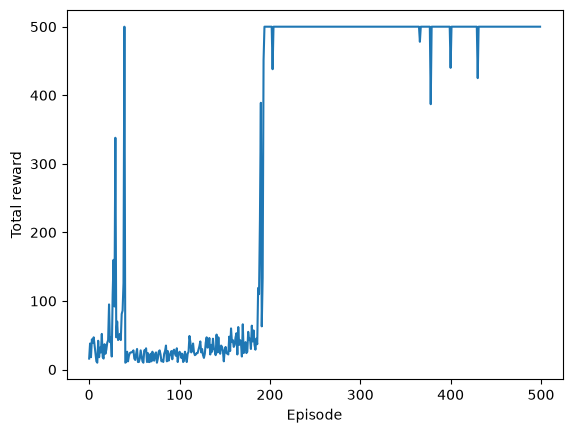

In [14]:
plt.plot(total_rewards)
plt.xlabel('Episode')
plt.ylabel('Total reward');

In [ ]:
# rets